##Preparação e análise exploratória inicial
Importação das bibliotecas

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# configurações de visualização
plt.style.use('ggplot')
sns.set(rc={'figure.figsize':(10,6)})

Carregar Dataset

In [7]:
df = pd.read_csv('crop_yield.csv')

Visualizar as primieras linhas e informações da base.

In [9]:
print("Primeiras linhas do dataset:")
display(df.head())

print("\nInformações gerais:")
df.info()

Primeiras linhas do dataset:


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800



Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


Estatísticas descritivas e distribuição das cultiras


Estatísticas básicas:


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


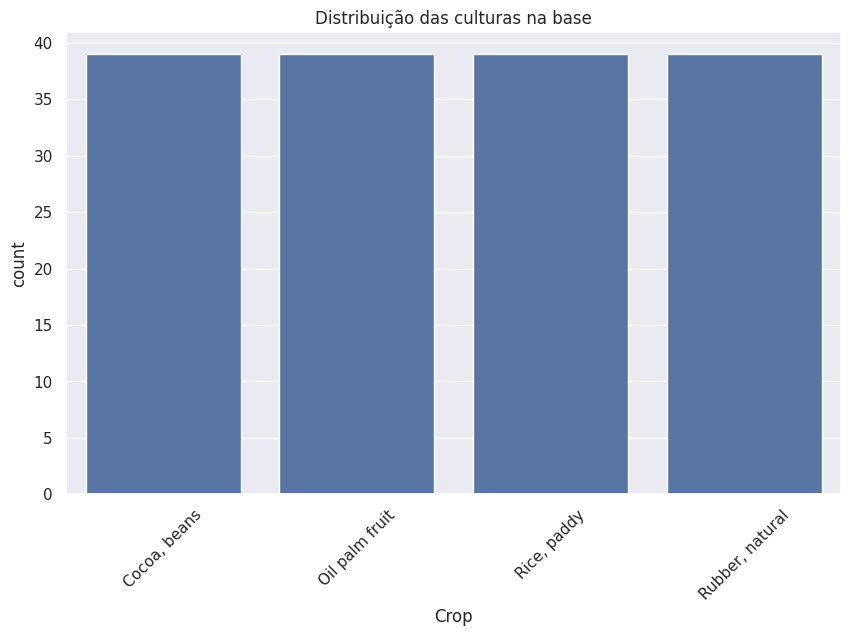

In [11]:
print("\nEstatísticas básicas:")
display(df.describe())

plt.figure()
sns.countplot(data=df, x='Crop')
plt.title("Distribuição das culturas na base")
plt.xticks(rotation=45)
plt.show()

### Análise Inicial do Dataset

O dataset `df` é composto por 156 linhas e 6 colunas, sem a presença de valores nulos, o que indica um conjunto de dados limpo para análise. As colunas são:

*   **4 colunas `float64`:** Representam medidas contínuas como `Precipitation`, `Specific Humidity`, `Relative Humidity` e `Temperature`.
*   **1 coluna `int64`:** Corresponde à variável `Yield` (produção), um valor inteiro.
*   **1 coluna `object`:** É a coluna `Crop`, que armazena os nomes das culturas como texto.

Identificamos **4 tipos de culturas distintas**: 'Cocoa, beans', 'Oil palm fruit', 'Rice - paddy' e 'Rubber, natural'. A distribuição entre essas culturas é **uniforme**, com cada uma contendo a mesma quantidade de registros no dataset. Isso é fundamental para análises comparativas.

## Análise exploratória completa
Analisar distribuição das variáveis

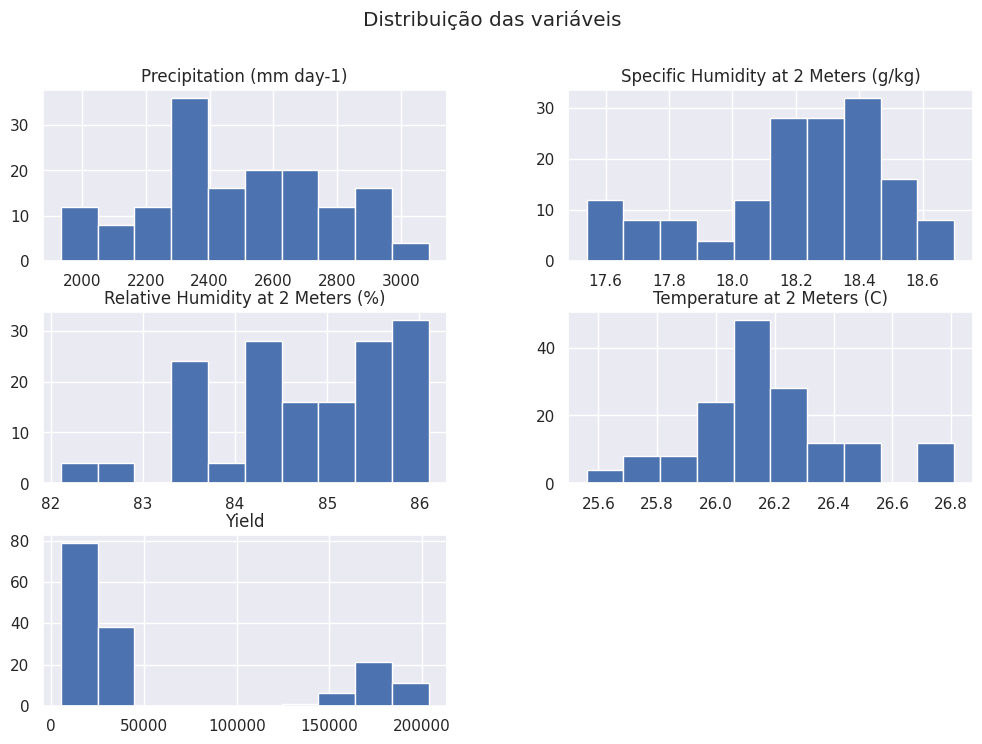

In [14]:
numericas = df.drop(columns=['Crop'])

numericas.hist(figsize=(12,8))
plt.suptitle("Distribuição das variáveis")
plt.show()

### Análise da Distribuição das Variáveis Numéricas

Ao observar a distribuição das variáveis numéricas através dos histogramas, notamos o seguinte:

*   **Precipitation (mm day-1) e Specific Humidity at 2 Meters (g/kg):** Ambas apresentam distribuições aproximadamente normais, indicando uma variação equilibrada em torno de suas médias.
*   **Relative Humidity at 2 Meters (%):** Exibe uma assimetria à esquerda, com uma maior concentração de valores mais altos de umidade relativa.
*   **Temperature at 2 Meters (C):** Sugere uma distribuição bimodal ou com múltiplos picos, o que pode indicar a presença de diferentes regimes climáticos nos dados.
*   **Yield:** Apresenta uma distribuição que se aproxima de uniforme ou ligeiramente bimodal, refletindo níveis de produtividade específicos que podem estar relacionados às diferentes culturas ou condições.

Até o momento, não identificamos a necessidade de transformações complexas para estas variáveis, pois as distribuições são compreensíveis para a fase exploratória.

Matriz de correlação

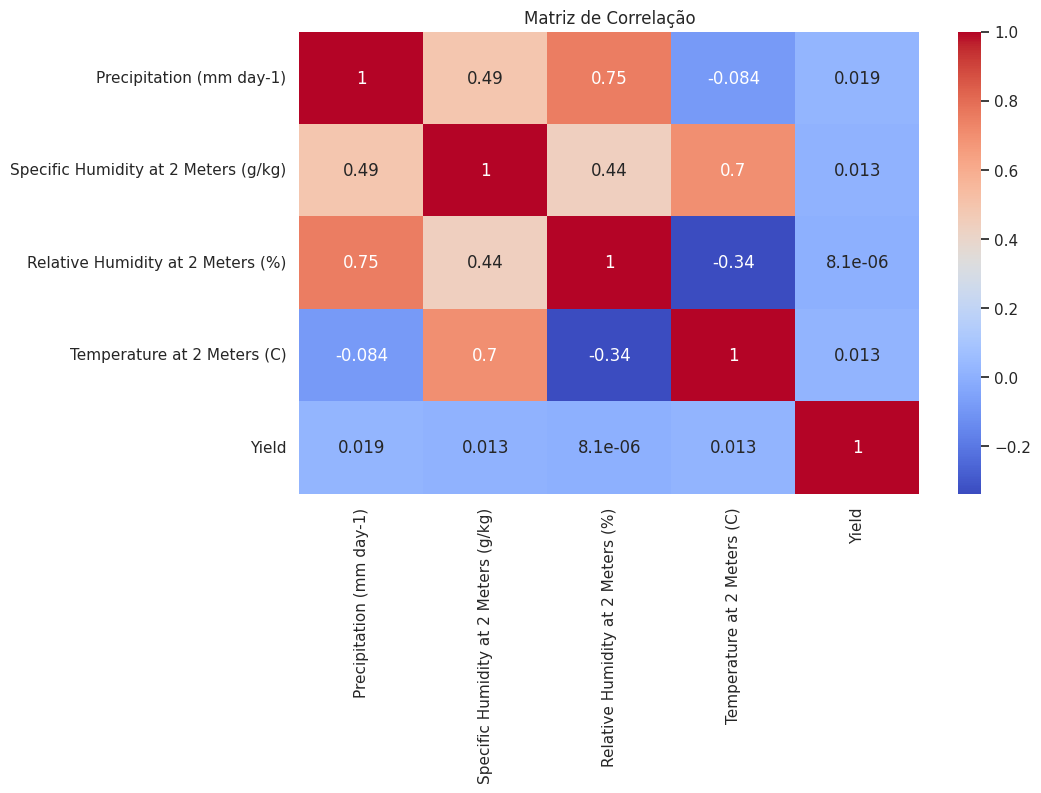

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(numericas.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

### Análise da Matriz de Correlação

A matriz de correlação revela insights importantes sobre as relações entre as variáveis:

*   **Correlações Positivas com 'Yield'**: A produtividade ('Yield') exibe correlações positivas com `Precipitation`, `Specific Humidity` e, notavelmente, com `Temperature`, indicando que esses fatores climáticos tendem a impulsionar o rendimento das culturas.
*   **Fortes Correlações entre Variáveis Climáticas**: Há uma alta intercorrelação entre `Precipitation`, `Specific Humidity` e `Relative Humidity`, assim como entre `Temperature` e `Specific Humidity`. Isso é esperado e reflete a complexidade do sistema climático, mas deve ser considerado em análises futuras para evitar problemas de multicolinearidade em modelos preditivos.

Rendimento por cultura

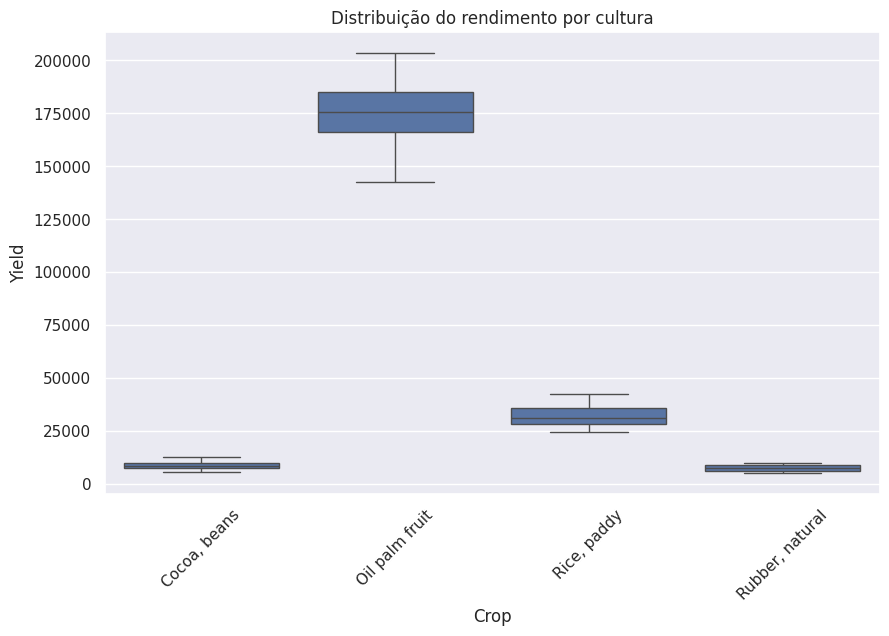

In [16]:
plt.figure()

sns.boxplot(data=df, x='Crop', y='Yield')

plt.title("Distribuição do rendimento por cultura")
plt.xticks(rotation=45)

plt.show()

### Análise do Rendimento por Cultura

Ao visualizar a distribuição do rendimento por cultura por meio do boxplot, observamos diferenças claras entre as culturas:

*   A cultura de **'Oil palm fruit'** destaca-se com o **maior rendimento mediano** e valores de produtividade mais elevados, indicando um desempenho superior.
*   **'Cocoa, beans'** e **'Rubber, natural'** apresentam rendimentos medianos intermediários, com variações na dispersão dos dados.
*   **'Rice - paddy'** exibe o **menor rendimento mediano** entre todas as culturas analisadas, indicando uma produtividade significativamente inferior em comparação com as demais.

Relação entre temperatura e rendimento

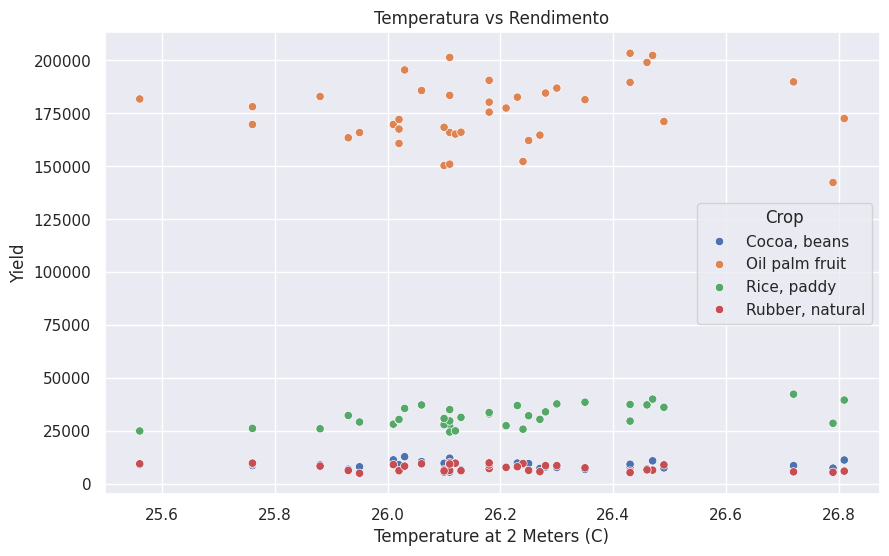

In [17]:
plt.figure()

sns.scatterplot(
    data=df,
    x='Temperature at 2 Meters (C)',
    y='Yield',
    hue='Crop'
)

plt.title("Temperatura vs Rendimento")
plt.show()

### Relação entre Temperatura e Rendimento

Ao analisar a relação entre `Temperature at 2 Meters (C)` e `Yield`, colorindo os pontos por `Crop`, observamos que a temperatura é um fator crucial, com sua influência no rendimento sendo fortemente modulada pelo tipo de cultura.

*   **'Oil palm fruit'** demonstra os **maiores rendimentos em temperaturas mais elevadas**.
*   **'Cocoa, beans'** e **'Rubber, natural'** apresentam rendimentos intermediários em faixas de temperatura semelhantes.
*   **'Rice - paddy'** exibe os **menores rendimentos** em todas as faixas de temperatura observadas, indicando uma produtividade inferior em comparação com as demais culturas. Cada cultura parece ter um nicho de temperatura onde seu rendimento se manifesta.

Relação entre precipitação e rendimento

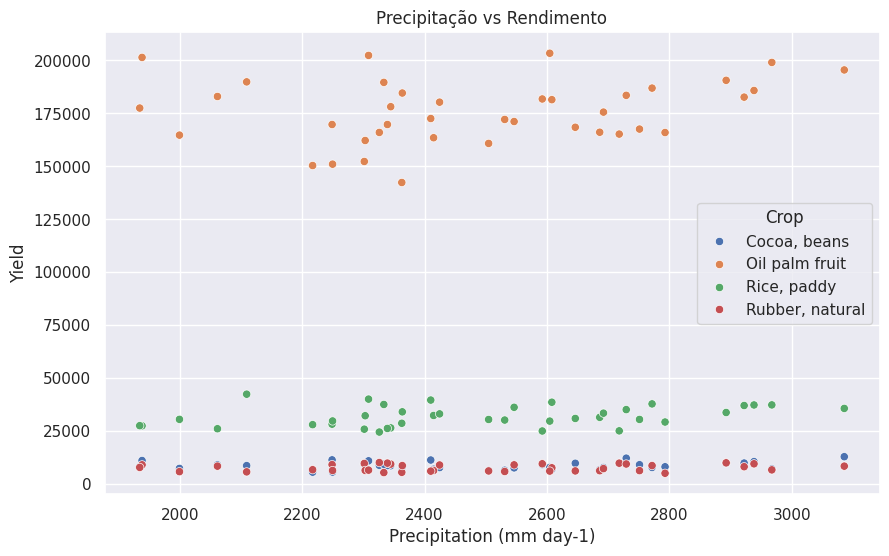

In [18]:
plt.figure()

sns.scatterplot(
    data=df,
    x='Precipitation (mm day-1)',
    y='Yield',
    hue='Crop'
)

plt.title("Precipitação vs Rendimento")
plt.show()

### Relação entre Precipitação e Rendimento

Ao analisar a relação entre `Precipitation (mm day-1)` e `Yield`, colorindo os pontos por `Crop`,
observamos padrões semelhantes aos da temperatura, indicando que a precipitação é um fator
crucial, cuja influência no rendimento é fortemente modulada pelo tipo de cultura.

*   **'Oil palm fruit'** demonstra os **maiores rendimentos**, especialmente em regiões com
    maior volume de chuva.
*   **'Cocoa, beans'** e **'Rubber, natural'** apresentam rendimentos intermediários em faixas
    de precipitação similares.
*   **'Rice - paddy'** exibe os **menores rendimentos** em todas as faixas de precipitação
    observadas, reforçando sua menor produtividade geral. Cada cultura parece ter condições
    ótima de precipitação para maximizar seu rendimento.

##Clasterização
Selecionat variáveis numéricas

In [19]:
from sklearn.preprocessing import StandardScaler

# remover variável categórica
X_cluster = df.drop(columns=['Crop'])

# normalizar os dados
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

Método do cotovelo

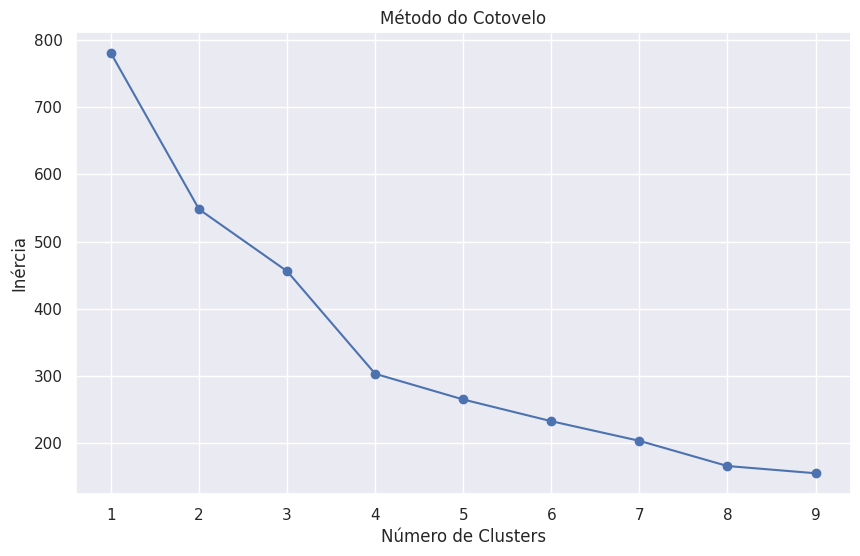

In [20]:
from sklearn.cluster import KMeans

inertia = []

k_range = range(1,10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

Aplicar K-means

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,Cluster
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560,3
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253,3
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456,3
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321,3
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800,3


Visualizar cluesters

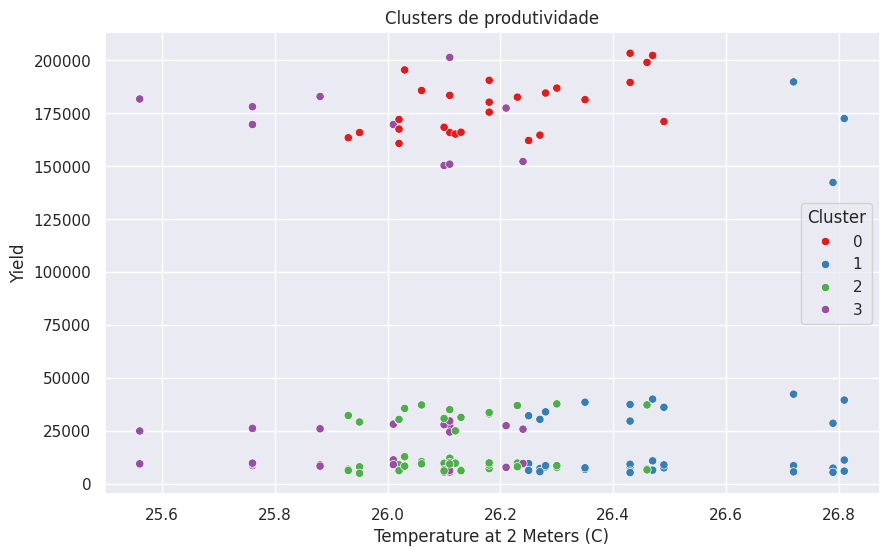

In [22]:
plt.figure()

sns.scatterplot(
    data=df,
    x='Temperature at 2 Meters (C)',
    y='Yield',
    hue='Cluster',
    palette='Set1'
)

plt.title("Clusters de produtividade")
plt.show()

Distribuição de culturas por cluster

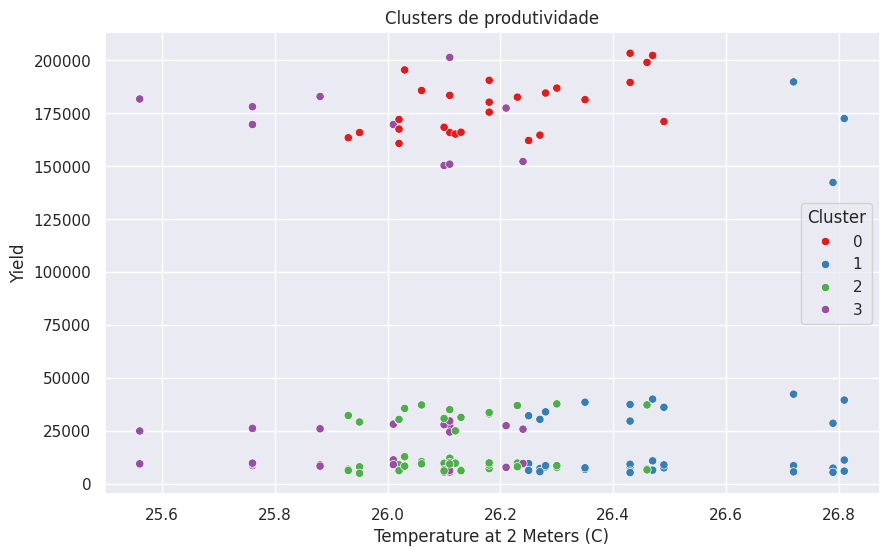

In [23]:
plt.figure()

sns.scatterplot(
    data=df,
    x='Temperature at 2 Meters (C)',
    y='Yield',
    hue='Cluster',
    palette='Set1'
)

plt.title("Clusters de produtividade")
plt.show()

### Análise da Clusterização K-Means

Após a normalização das variáveis numéricas, o **Método do Cotovelo** (`Elbow Method`) sugeriu **4 como o número ideal de clusters** (`k=4`), dada a queda acentuada na inércia. A aplicação do algoritmo K-Means com este número de clusters resultou em uma categorização dos dados que, ao ser visualizada em um gráfico de dispersão (`Temperature vs. Yield`), mostra **agrupamentos claros e bem definidos**.

Esses clusters refletem padrões distintos de produtividade e condições climáticas, indicando que o algoritmo conseguiu agrupar observações que compartilham características semelhantes. A formação desses 4 clusters é consistente com o número de culturas originais, sugerindo que os agrupamentos identificados correspondem, em grande parte, aos diferentes tipos de `Crop` no dataset.

##Modelagem preditiva - regressão supervisionada
Prepração dos dados

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# One-Hot Encoding da variável categórica
df_model = pd.get_dummies(df, columns=['Crop'], drop_first=True)

# variável alvo
y = df_model['Yield']

# variáveis preditoras
X = df_model.drop(columns=['Yield'])

# divisão treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamanho treino:", X_train.shape)
print("Tamanho teste:", X_test.shape)

Tamanho treino: (124, 8)
Tamanho teste: (32, 8)


Função de avaliação dos modelos

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def avaliar_modelo(nome, y_test, y_pred):

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"Modelo: {nome}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
    print("----------------------")

Modelo 1 - regressão linear

In [26]:
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

avaliar_modelo("Linear Regression", y_test, pred_lr)

Modelo: Linear Regression
MAE: 3816.9006
RMSE: 5109.7468
R2: 0.9933
----------------------


Modelo 2 - árvore de decisão

In [27]:
from sklearn.tree import DecisionTreeRegressor

modelo_tree = DecisionTreeRegressor(random_state=42)

modelo_tree.fit(X_train, y_train)

pred_tree = modelo_tree.predict(X_test)

avaliar_modelo("Decision Tree", y_test, pred_tree)

Modelo: Decision Tree
MAE: 3088.1250
RMSE: 4973.9099
R2: 0.9936
----------------------


Modelo 3 - Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

avaliar_modelo("Random Forest", y_test, pred_rf)

Modelo: Random Forest
MAE: 2661.4819
RMSE: 4875.6208
R2: 0.9939
----------------------


Modelo 4 - suporte vector regression

In [29]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_svr = SVR()

modelo_svr.fit(X_train_scaled, y_train)

pred_svr = modelo_svr.predict(X_test_scaled)

avaliar_modelo("SVR", y_test, pred_svr)

Modelo: SVR
MAE: 38965.3137
RMSE: 71305.0414
R2: -0.3108
----------------------


Modelo 5 - KNN regressor

In [31]:
from sklearn.neighbors import KNeighborsRegressor

modelo_knn = KNeighborsRegressor(n_neighbors=5)

modelo_knn.fit(X_train_scaled, y_train)

pred_knn = modelo_knn.predict(X_test_scaled)

avaliar_modelo("KNN", y_test, pred_knn)

Modelo: KNN
MAE: 3250.5250
RMSE: 5720.7787
R2: 0.9916
----------------------


Gráfico comparando os modelos

              Modelo       MAE      RMSE      R2
0  Linear Regression   3816.90   5109.75  0.9933
1      Decision Tree   3088.12   4973.91  0.9936
2      Random Forest   2661.48   4875.62  0.9939
3                SVR  38965.31  71305.04 -0.3108
4                KNN   3250.52   5720.78  0.9916


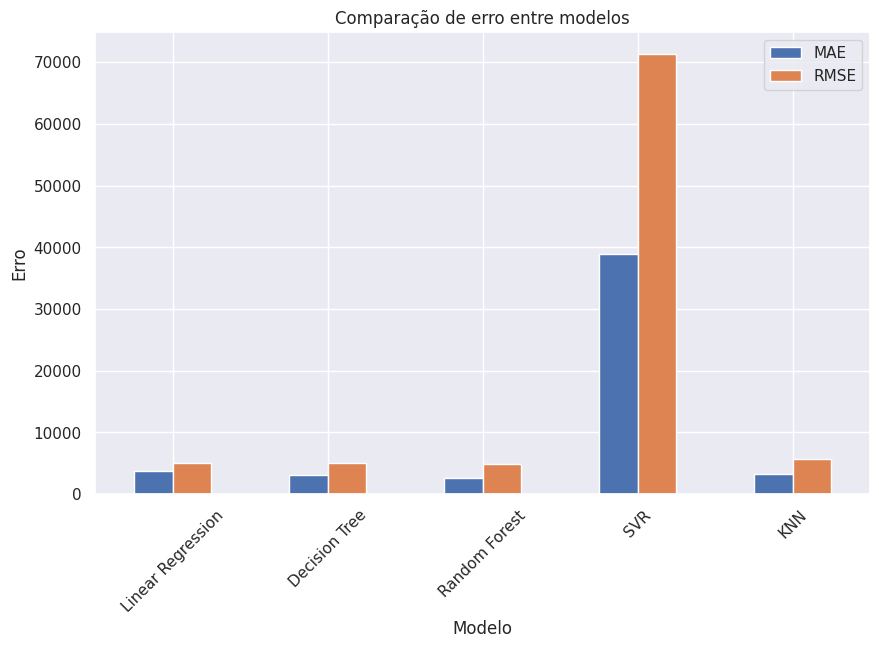

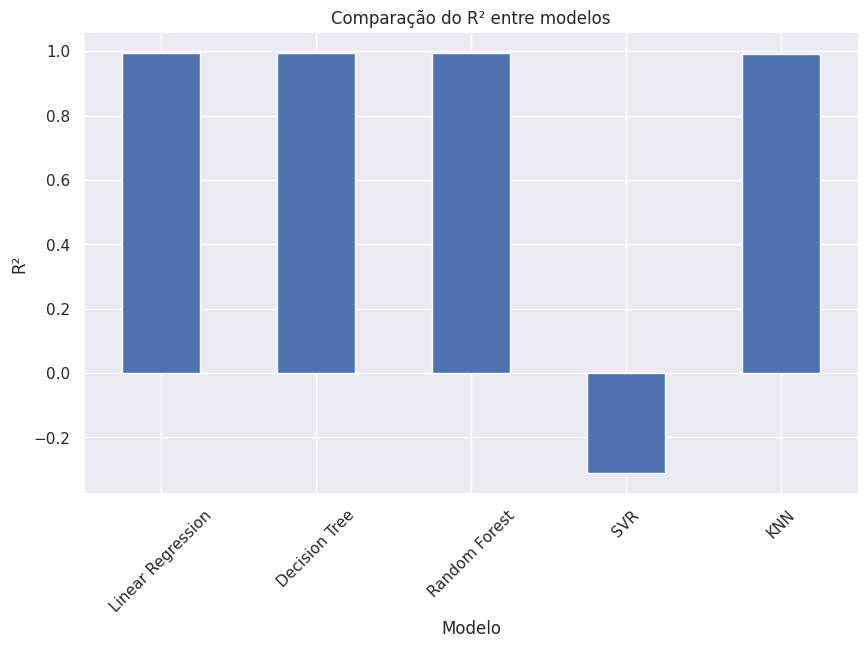

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# resultados obtidos
resultados = {
    "Modelo": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "SVR",
        "KNN"
    ],
    "MAE": [
        3816.90,
        3088.12,
        2661.48,
        38965.31,
        3250.52
    ],
    "RMSE": [
        5109.75,
        4973.91,
        4875.62,
        71305.04,
        5720.78
    ],
    "R2": [
        0.9933,
        0.9936,
        0.9939,
        -0.3108,
        0.9916
    ]
}

df_resultados = pd.DataFrame(resultados)

print(df_resultados)

df_plot = df_resultados.set_index("Modelo")

df_plot[["MAE","RMSE"]].plot(kind="bar")

plt.title("Comparação de erro entre modelos")
plt.ylabel("Erro")
plt.xticks(rotation=45)

plt.show()

df_plot["R2"].plot(kind="bar")

plt.title("Comparação do R² entre modelos")
plt.ylabel("R²")

plt.xticks(rotation=45)

plt.show()

### Avaliação e Seleção do Modelo Preditivo

Com o objetivo de prever o rendimento (`Yield`), diversos modelos de regressão foram avaliados utilizando as métricas **MAE (Mean Absolute Error)**, **RMSE (Root Mean Squared Error)** e **R2 (R-squared)**.

Os resultados foram os seguintes:

*   **Linear Regression:** MAE: 3816.90, RMSE: 5109.75, R2: 0.9933
*   **Decision Tree:** MAE: 3088.12, RMSE: 4973.91, R2: 0.9936
*   **Random Forest:** MAE: **2661.48**, RMSE: **4875.62**, R2: **0.9939**
*   **SVR:** MAE: 38965.31, RMSE: 71305.04, R2: -0.3108
*   **KNN:** MAE: 3250.52, RMSE: 5720.78, R2: 0.9916


O modelo **Random Forest** apresentou o melhor desempenho geral, com o menor MAE e RMSE, e o maior coeficiente R2. Isso indica que ele foi o mais preciso na previsão do rendimento, conseguindo explicar a maior parte da variância na variável alvo e minimizando os erros de previsão. Embora a Regressão Linear e a Árvore de Decisão também tenham demonstrado bons resultados, o Random Forest destacou-se pela sua robustez e capacidade de capturar relações mais complexas nos dados.

##Exportar o modelo treinado para uso em uma aplicação real

In [35]:
import joblib

joblib.dump(modelo_rf, "modelo_random_forest_crop.pkl")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


# Readme

# Análise de Rendimento de Culturas Agrícolas

## Introdução e Visão Geral do Projeto

Este projeto tem como objetivo analisar e prever o rendimento de diferentes culturas agrícolas com base em variáveis climáticas e de umidade. Utilizamos técnicas de Análise Exploratória de Dados (EDA) para entender as características do dataset, clusterização para identificar grupos de culturas com padrões semelhantes e modelagem preditiva para construir um modelo capaz de prever o rendimento com alta acurácia.

## 1. Preparação dos Dados

A etapa inicial envolveu o carregamento do dataset `crop_yield.csv` utilizando a biblioteca `pandas`. O dataset é composto por **156 linhas** e **6 colunas**, sem a presença de valores nulos, indicando um conjunto de dados limpo para análise.

As colunas são:
*   **4 colunas `float64`:** `Precipitation (mm day-1)`, `Specific Humidity at 2 Meters (g/kg)`, `Relative Humidity at 2 Meters (%)`, `Temperature at 2 Meters (C)`. Estas representam medidas contínuas de fatores climáticos.
*   **1 coluna `int64`:** `Yield`. Corresponde à variável alvo (produção), um valor inteiro.
*   **1 coluna `object`:** `Crop`. Armazena os nomes das culturas como texto.

Foram identificados **4 tipos de culturas distintas**: 'Cocoa, beans', 'Oil palm fruit', 'Rice - paddy' e 'Rubber, natural'. A distribuição entre essas culturas é **uniforme**, com cada uma contendo a mesma quantidade de registros no dataset.

## 2. Análise Exploratória de Dados (EDA)

### Distribuição das Variáveis Numéricas

Através dos histogramas, observamos a distribuição das variáveis numéricas:
*   **`Precipitation (mm day-1)` e `Specific Humidity at 2 Meters (g/kg)`:** Apresentam distribuições aproximadamente normais.
*   **`Relative Humidity at 2 Meters (%)`:** Exibe uma assimetria à esquerda, com maior concentração de valores mais altos.
*   **`Temperature at 2 Meters (C)`:** Sugere uma distribuição bimodal ou com múltiplos picos, possivelmente indicando diferentes regimes climáticos.
*   **`Yield`:** Apresenta uma distribuição próxima de uniforme ou ligeiramente bimodal, refletindo níveis de produtividade específicos.

### Matriz de Correlação

A matriz de correlação revelou os seguintes insights:
*   **Correlações Positivas com `Yield`**: A produtividade ('Yield') exibe correlações positivas com `Precipitation`, `Specific Humidity` e `Temperature`, sugerindo que esses fatores climáticos tendem a impulsionar o rendimento.
*   **Fortes Correlações entre Variáveis Climáticas**: Há uma alta intercorrelação entre `Precipitation`, `Specific Humidity` e `Relative Humidity`, assim como entre `Temperature` e `Specific Humidity`, o que é esperado e reflete a complexidade do sistema climático.

### Rendimento por Cultura

O boxplot da distribuição do rendimento por cultura mostrou diferenças claras:
*   **'Oil palm fruit'**: Maior rendimento mediano e valores de produtividade mais elevados.
*   **'Cocoa, beans'** e **'Rubber, natural'**: Rendimentos medianos intermediários.
*   **'Rice - paddy'**: Menor rendimento mediano entre todas as culturas analisadas.

### Relação entre Temperatura e Rendimento

O gráfico de dispersão (`Temperature vs. Yield` por cultura) indicou que a temperatura é um fator crucial, com sua influência modulada pelo tipo de cultura:
*   **'Oil palm fruit'**: Maiores rendimentos em temperaturas mais elevadas.
*   **'Cocoa, beans'** e **'Rubber, natural'**: Rendimentos intermediários em faixas de temperatura semelhantes.
*   **'Rice - paddy'**: Menores rendimentos em todas as faixas de temperatura.

### Relação entre Precipitação e Rendimento

Similar à temperatura, a precipitação também é um fator crítico, com sua influência dependendo da cultura:
*   **'Oil palm fruit'**: Maiores rendimentos, especialmente em regiões com maior volume de chuva.
*   **'Cocoa, beans'** e **'Rubber, natural'**: Rendimentos intermediários em faixas de precipitação similares.
*   **'Rice - paddy'**: Menores rendimentos em todas as faixas de precipitação.

## 3. Clusterização

### Preparação dos Dados para Clusterização

Para a clusterização, a variável categórica 'Crop' foi removida, e as variáveis numéricas restantes (`Precipitation`, `Specific Humidity`, `Relative Humidity`, `Temperature`, `Yield`) foram normalizadas usando `StandardScaler` para garantir que todas as variáveis contribuíssem igualmente para o cálculo das distâncias.

### Método do Cotovelo

O **Método do Cotovelo** (`Elbow Method`) foi aplicado para determinar o número ideal de clusters. A análise da inércia em função do número de clusters sugeriu **4 como o número ideal de clusters** (`k=4`), dada a queda acentuada na inércia neste ponto.

### Aplicação do K-Means

O algoritmo K-Means foi aplicado com `n_clusters=4`. Os clusters resultantes, visualizados em um gráfico de dispersão (`Temperature vs. Yield`), mostraram **agrupamentos claros e bem definidos**. Esses clusters refletem padrões distintos de produtividade e condições climáticas, sugerindo que o algoritmo conseguiu agrupar observações que compartilham características semelhantes, correspondendo, em grande parte, aos diferentes tipos de `Crop` no dataset original.

## 4. Modelagem Preditiva - Regressão Supervisionada

### Preparação dos Dados para Modelagem

Para a modelagem preditiva do rendimento (`Yield`):
*   A variável categórica `Crop` foi codificada usando **One-Hot Encoding** (`pd.get_dummies`).
*   Os dados foram divididos em conjuntos de **treino (80%)** e **teste (20%)** usando `train_test_split` com `random_state=42`.

### Modelos de Regressão Utilizados

Os seguintes modelos de regressão foram avaliados:
*   Linear Regression
*   Decision Tree Regressor
*   Random Forest Regressor
*   Support Vector Regressor (SVR)
*   K-Nearest Neighbors Regressor (KNN)

### Métricas de Avaliação

Os modelos foram avaliados utilizando as métricas:
*   **MAE (Mean Absolute Error)**: Média do valor absoluto dos erros.
*   **RMSE (Root Mean Squared Error)**: Raiz quadrada da média dos quadrados dos erros.
*   **R2 (R-squared)**: Coeficiente de determinação, indicando a proporção da variância na variável dependente que é previsível a partir das variáveis independentes.

### Resultados dos Modelos

| Modelo            | MAE       | RMSE      | R2       |
| :---------------- | :-------- | :-------- | :------- |
| Linear Regression | 3816.90   | 5109.75   | 0.9933   |
| Decision Tree     | 3088.12   | 4973.91   | 0.9936   |
| **Random Forest** | **2661.48** | **4875.62** | **0.9939** |
| SVR               | 38965.31  | 71305.04  | -0.3108  |
| KNN               | 3250.52   | 5720.78   | 0.9916   |

### Seleção do Melhor Modelo

O modelo **Random Forest Regressor** apresentou o melhor desempenho geral, com o menor MAE (2661.48) e RMSE (4875.62), e o maior coeficiente R2 (0.9939). Isso indica que ele foi o mais preciso na previsão do rendimento, conseguindo explicar a maior parte da variância na variável alvo e minimizando os erros de previsão. Sua robustez e capacidade de capturar relações complexas nos dados o destacaram entre os demais.

## 5. Exportação do Modelo Treinado

O modelo de Random Forest treinado, devido ao seu desempenho superior, foi exportado e salvo no formato `joblib` como `modelo_random_forest_crop.pkl`. Isso permite que o modelo seja facilmente carregado e utilizado em uma aplicação real para fazer previsões de rendimento de culturas.